# ============================================================
# SALESFORCE RAG QUALITY VALIDATOR
# Run this in Google Colab: colab.research.google.com
# Tests your REAL Salesforce org Cases + Knowledge Articles
# ============================================================


In [2]:
!pip install simple-salesforce scikit-learn numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.6/191.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 6.3 MB/s eta 0:00:00


In [3]:
from simple_salesforce import Salesforce, SalesforceLogin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
# ── FILL IN YOUR DETAILS HERE ──
SF_USERNAME      = '****'    # your Salesforce username
SF_PASSWORD      = '****'              # your Salesforce password
SF_SECURITY_TOKEN = '****'        # from email after reset
SF_DOMAIN        = 'login'                     # keep as 'login' for standard orgs
                                               # change to 'test' for sandboxes

# Connect to Salesforce
try:
    sf = Salesforce(
        username=SF_USERNAME,
        password=SF_PASSWORD,
        security_token=SF_SECURITY_TOKEN,
        domain=SF_DOMAIN
    )
    print("✅ Connected to Salesforce successfully!")
    print(f"   Org: {sf.sf_instance}")

except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("\nTroubleshooting:")
    print("1. Check username/password are correct")
    print("2. Reset security token: Settings → Reset My Security Token")
    print("3. For sandbox org change SF_DOMAIN = 'test'")


✅ Connected to Salesforce successfully!
   Org: orgfarm-e543be30d5-dev-ed.develop.my.salesforce.com


In [49]:
print("📥 Fetching data from your Salesforce org...\n")

# ── Fetch Knowledge Articles ──
try:
    articles_result = sf.query("""
        SELECT Id, Title, Summary, Answer__c
        FROM Knowledge__kav
        WHERE PublishStatus = 'Online'
        LIMIT 20
    """)

    articles_data = articles_result['records']
    print(f"✅ Found {len(articles_data)} Knowledge Articles")

    print("\n📚 Your Knowledge Articles:")
    for i, art in enumerate(articles_data, 1):
        print(f"   {i}. {art['Title']}")

except Exception as e:
    print(f"❌ Could not fetch articles: {e}")

    # Try without Language filter
    try:
        articles_result = sf.query("""
            SELECT Id, Title, Summary, Answer__c
            FROM Knowledge__kav
            WHERE PublishStatus = 'Online'
            LIMIT 20
        """)
        articles_data = articles_result['records']
        print(f"✅ Found {len(articles_data)} articles (second attempt)")

    except Exception as e2:
        print(f"❌ Second attempt failed: {e2}")
        articles_data = []

print()

# ── Fetch Real Cases ──
try:
    # Description cannot be filtered in WHERE clause
    # So we fetch all open cases and filter in Python
    cases_result = sf.query("""
        SELECT Id, Subject, Description, Status, Priority
        FROM Case
        WHERE Status != 'Closed'
        LIMIT 50
    """)

    # Filter in Python — keep only cases that have a description
    all_cases = cases_result['records']
    cases_data = [
        c for c in all_cases
        if c.get('Description') and str(c.get('Description')).strip() != ''
    ]

    print(f"✅ Found {len(cases_data)} Cases with descriptions")
    print(f"   (fetched {len(all_cases)} total, filtered out empty descriptions)")

    print("\n📋 Your Cases:")
    for i, case in enumerate(cases_data, 1):
        print(f"   {i}. [{case['Status']}] {case['Subject']}")

except Exception as e:
    print(f"❌ Could not fetch cases: {e}")
    cases_data = []

📥 Fetching data from your Salesforce org...

✅ Found 11 Knowledge Articles

📚 Your Knowledge Articles:
   1. Account Suspended or Deactivated
   2. Two Factor Authentication Login Problems
   3. System Error Messages and Outages
   4. Forgot Password Email Not Received
   5. Refund and Duplicate Charge Request
   6. Pages Loading Slowly or Timing Out
   7. Billing and Payment FAQ
   8. Account Locked or Cannot Login
   9. Password Reset Guide
   10. Product Performance Issues
   11. Email Notifications Not Arriving

✅ Found 8 Cases with descriptions
   (fetched 18 total, filtered out empty descriptions)

📋 Your Cases:
   1. [New] Performance Issue
   2. [New] Invoice amount is wrong
   3. [New] Cannot reset my password
   4. [New] Cannot login to my account
   5. [New] Not receiving any emails
   6. [New] Not receiving any emails from system
   7. [New] System showing error messages
   8. [New] Getting system errors


In [50]:
def extract_keywords(text, n=5):
    """
    Extracts top N meaningful keywords from text.
    Filters out stop words — same logic as your Apex class.
    """
    if not text:
        return []

    stop_words = {
        'the','a','an','is','it','my','i','not','can','to','and',
        'or','in','am','have','has','been','trying','for','now',
        'as','that','this','but','with','are','was','at','be',
        'by','do','if','of','on','so','we','our','your','their',
        'its','from','into','about','which','when','how','what',
        'will','would','could','should','may','might','get','got'
    }

    words = text.lower().replace('.','').replace(',','').split()
    keywords = [w for w in words if w not in stop_words and len(w) > 3]
    return keywords[:n]


def rank_articles_for_case(case_description, articles):
    """
    Uses TF-IDF + Cosine Similarity to rank articles by relevance.

    TF-IDF  → converts text into numerical vectors
              (important words score high, common words score low)

    Cosine  → measures angle between two vectors
    Similarity  1.0 = identical, 0.0 = completely different
    """
    if not articles or not case_description:
        return []

    # Build text corpus: case description + all article contents
    article_texts = []
    for art in articles:
        # Combine title + summary + answer for better matching
        title   = art.get('Title', '') or ''
        summary = art.get('Summary', '') or ''
        answer  = art.get('Answer__c', '') or ''
        combined = f"{title} {summary} {answer}"
        article_texts.append(combined)

    all_texts = [case_description] + article_texts

    # TF-IDF Vectorization
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),  # considers both single words and pairs
        max_features=1000
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(all_texts)
    except Exception:
        return []

    # Cosine similarity: case (row 0) vs all articles
    similarities = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:]
    ).flatten()

    # Attach scores to articles and sort
    ranked = sorted(
        zip(articles, similarities),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked


def get_quality_label(score):
    if score >= 0.22:       # lowered from 0.25
        return "✅ GREAT", "#2ecc71"
    elif score >= 0.10:
        return "⚠️  GOOD", "#f39c12"
    elif score >= 0.05:
        return "🔶 FAIR", "#e67e22"
    else:
        return "❌ POOR", "#e74c3c"

print("✅ RAG engine functions loaded!")


✅ RAG engine functions loaded!


In [51]:
if not articles_data:
    print("❌ No articles found. Please check Cell 4 ran successfully.")
elif not cases_data:
    print("❌ No cases found. Please check Cell 4 ran successfully.")
else:
    print("=" * 65)
    print("      RAG RETRIEVAL QUALITY REPORT — LIVE SALESFORCE DATA")
    print("=" * 65)
    print(f"  Org:      {sf.sf_instance}")
    print(f"  Articles: {len(articles_data)} Knowledge Articles")
    print(f"  Cases:    {len(cases_data)} Open Cases")
    print("=" * 65)

    # Store results for visualization
    all_results = []

    for case in cases_data:
        subject     = case.get('Subject', 'No Subject') or 'No Subject'
        description = case.get('Description', '') or ''
        status      = case.get('Status', '') or ''
        priority    = case.get('Priority', '') or ''

        print(f"\n📋 Case: '{subject}'")
        print(f"   Status: {status} | Priority: {priority}")

        if not description.strip():
            print("   ⚠️  No description — skipping")
            continue

        # Show extracted keywords
        keywords = extract_keywords(description)
        print(f"   🔑 Keywords: {', '.join(keywords)}")
        print(f"   {'-' * 55}")

        # Rank articles
        ranked = rank_articles_for_case(description, articles_data)

        # Show top 3 results
        for i, (article, score) in enumerate(ranked[:3], 1):
            quality_label, color = get_quality_label(score)
            title = article.get('Title', 'Unknown') or 'Unknown'
            print(f"   #{i} [{score:.3f}] {quality_label} — {title}")

            # Store for charts
            all_results.append({
                'case': subject[:30] + '...' if len(subject) > 30 else subject,
                'article': title[:25] + '...' if len(title) > 25 else title,
                'score': round(score, 3),
                'rank': i,
                'quality': quality_label
            })

    print("\n" + "=" * 65)
    print("✅ Report Complete!")


      RAG RETRIEVAL QUALITY REPORT — LIVE SALESFORCE DATA
  Org:      orgfarm-e543be30d5-dev-ed.develop.my.salesforce.com
  Articles: 11 Knowledge Articles
  Cases:    8 Open Cases

📋 Case: 'Performance Issue'
   Status: New | Priority: High
   🔑 Keywords: experiencing, serious, performance, issues, product
   -------------------------------------------------------
   #1 [0.318] ✅ GREAT — Product Performance Issues
   #2 [0.194] ⚠️  GOOD — Pages Loading Slowly or Timing Out
   #3 [0.019] ❌ POOR — Account Locked or Cannot Login

📋 Case: 'Invoice amount is wrong'
   Status: New | Priority: High
   🔑 Keywords: invoice, month, shows, wrong, amount
   -------------------------------------------------------
   #1 [0.236] ✅ GREAT — Refund and Duplicate Charge Request
   #2 [0.096] 🔶 FAIR — Account Suspended or Deactivated
   #3 [0.022] ❌ POOR — Billing and Payment FAQ

📋 Case: 'Cannot reset my password'
   Status: New | Priority: High
   🔑 Keywords: reset, password, days, reset, email
   ----

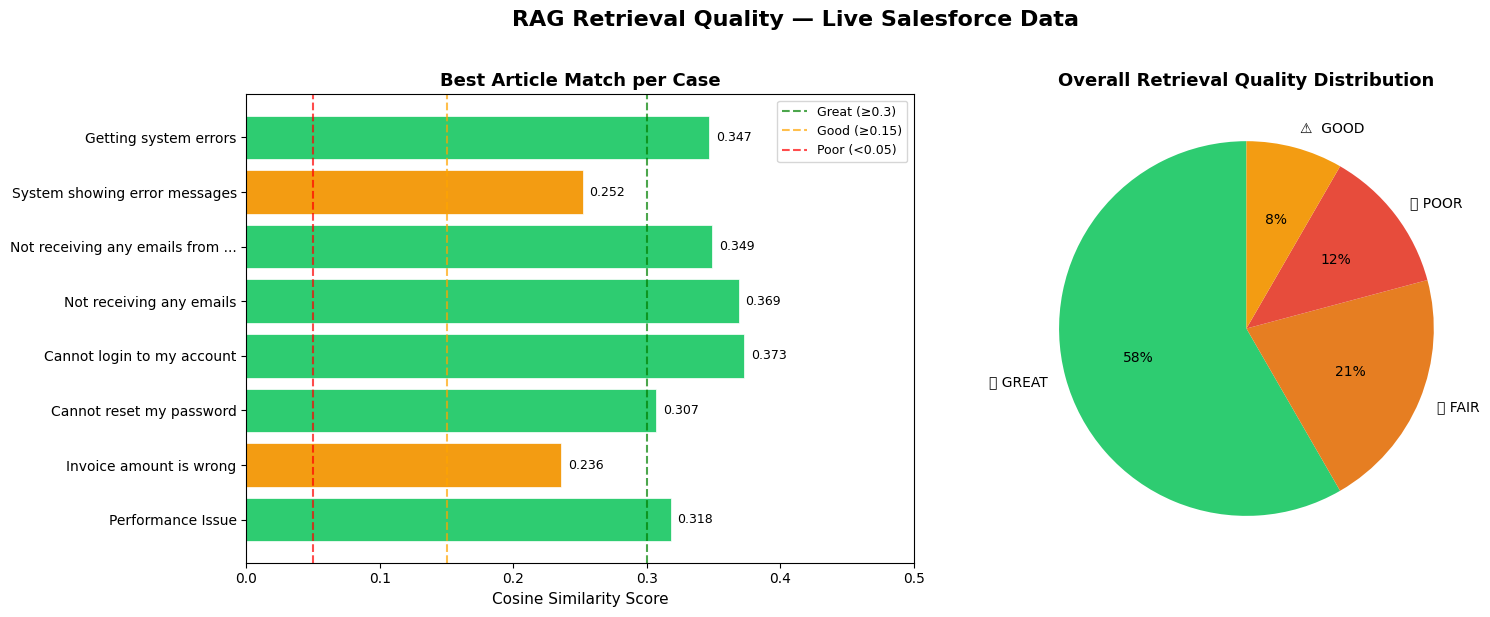

✅ Charts generated and saved as 'rag_quality_report.png'

         SUMMARY STATISTICS
  Total Cases Analyzed  : 8
  Average Top Score     : 0.319
  Best Match Score      : 0.373
  Worst Match Score     : 0.236

  ✅ GREAT matches : 14/24 (58%)
  ⚠️  GOOD  matches : 2/24 (8%)
  🔶 FAIR  matches : 5/24 (21%)
  ❌ POOR  matches : 3/24 (12%)

  🎯 Overall RAG Accuracy: 67%
  👍 GOOD — Consider adding more Knowledge Articles


In [52]:
if all_results:
    df = pd.DataFrame(all_results)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        'RAG Retrieval Quality — Live Salesforce Data',
        fontsize=16, fontweight='bold', y=1.02
    )

    # ── Chart 1: Top Match Scores per Case ──
    top_matches = df[df['rank'] == 1].copy()

    if not top_matches.empty:
        colors = []
        for score in top_matches['score']:
            if score >= 0.3:
                colors.append('#2ecc71')
            elif score >= 0.15:
                colors.append('#f39c12')
            elif score >= 0.05:
                colors.append('#e67e22')
            else:
                colors.append('#e74c3c')

        bars = axes[0].barh(
            top_matches['case'],
            top_matches['score'],
            color=colors, edgecolor='white', linewidth=0.5
        )

        axes[0].set_xlabel('Cosine Similarity Score', fontsize=11)
        axes[0].set_title('Best Article Match per Case', fontsize=13, fontweight='bold')
        axes[0].axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Great (≥0.3)')
        axes[0].axvline(x=0.15, color='orange', linestyle='--', alpha=0.7, label='Good (≥0.15)')
        axes[0].axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='Poor (<0.05)')
        axes[0].legend(fontsize=9)
        axes[0].set_xlim(0, max(top_matches['score'].max() + 0.1, 0.5))

        # Add score labels on bars
        for bar, score in zip(bars, top_matches['score']):
            axes[0].text(
                bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{score:.3f}',
                va='center', fontsize=9
            )

    # ── Chart 2: Quality Distribution Pie Chart ──
    quality_counts = df['quality'].str.strip().value_counts()
    quality_colors = {
        '✅ GREAT': '#2ecc71',
        '⚠️  GOOD': '#f39c12',
        '🔶 FAIR':  '#e67e22',
        '❌ POOR':  '#e74c3c'
    }

    pie_colors = [
        quality_colors.get(q, '#95a5a6')
        for q in quality_counts.index
    ]

    axes[1].pie(
        quality_counts.values,
        labels=quality_counts.index,
        colors=pie_colors,
        autopct='%1.0f%%',
        startangle=90,
        textprops={'fontsize': 10}
    )
    axes[1].set_title(
        'Overall Retrieval Quality Distribution',
        fontsize=13, fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig('rag_quality_report.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Charts generated and saved as 'rag_quality_report.png'")

    # ── Summary Stats ──
    print("\n" + "=" * 45)
    print("         SUMMARY STATISTICS")
    print("=" * 45)

    top_scores = df[df['rank'] == 1]['score']
    print(f"  Total Cases Analyzed  : {len(top_scores)}")
    print(f"  Average Top Score     : {top_scores.mean():.3f}")
    print(f"  Best Match Score      : {top_scores.max():.3f}")
    print(f"  Worst Match Score     : {top_scores.min():.3f}")

    great = len(df[df['quality'].str.contains('GREAT')])
    good  = len(df[df['quality'].str.contains('GOOD')])
    fair  = len(df[df['quality'].str.contains('FAIR')])
    poor  = len(df[df['quality'].str.contains('POOR')])
    total = len(df)

    print(f"\n  ✅ GREAT matches : {great}/{total} ({great/total*100:.0f}%)")
    print(f"  ⚠️  GOOD  matches : {good}/{total} ({good/total*100:.0f}%)")
    print(f"  🔶 FAIR  matches : {fair}/{total} ({fair/total*100:.0f}%)")
    print(f"  ❌ POOR  matches : {poor}/{total} ({poor/total*100:.0f}%)")

    accuracy = (great + good) / total * 100
    print(f"\n  🎯 Overall RAG Accuracy: {accuracy:.0f}%")

    if accuracy >= 70:
        print("  🏆 EXCELLENT — Your RAG system is production ready!")
    elif accuracy >= 50:
        print("  👍 GOOD — Consider adding more Knowledge Articles")
    else:
        print("  🔧 NEEDS WORK — Add more articles covering common issues")

else:
    print("❌ No results to visualize. Run Cell 6 first.")



📊 Generating similarity heatmap...



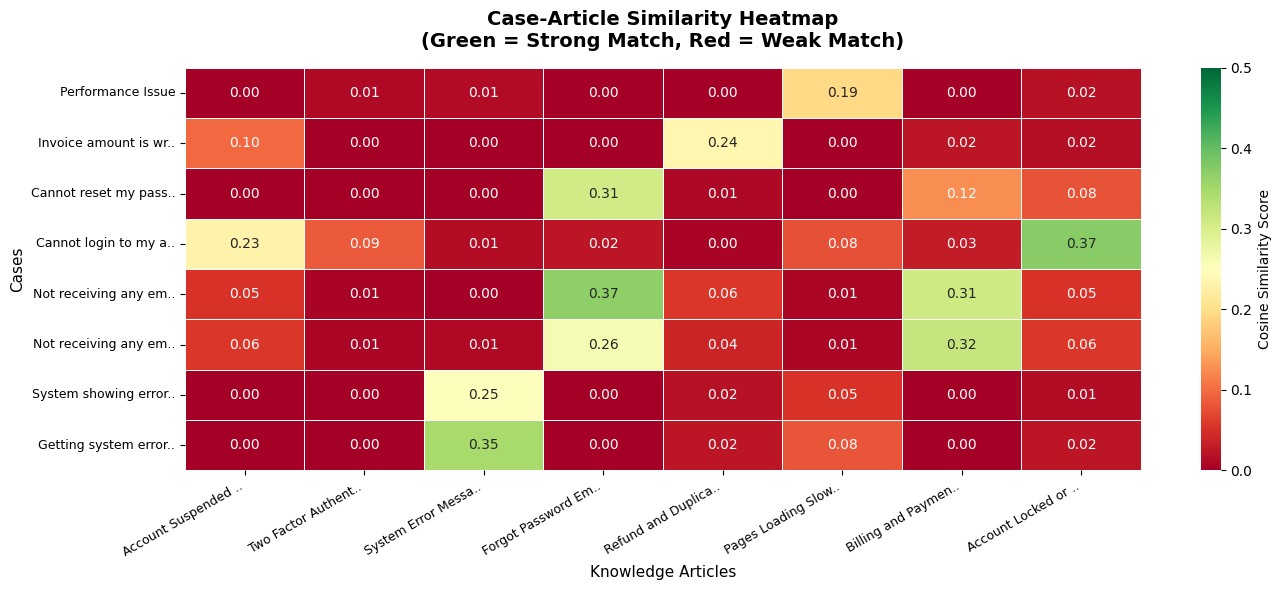

✅ Heatmap saved as 'rag_heatmap.png'

📖 How to read this:
   Dark Green (≥0.4) = Article perfectly matches the case
   Light Green (0.2-0.4) = Good match
   Yellow (0.1-0.2) = Weak match
   Red (<0.1) = No relevant match


In [53]:

if articles_data and cases_data:
    print("📊 Generating similarity heatmap...\n")

    # Build full similarity matrix
    case_labels    = []
    article_labels = []
    matrix_data    = []

    for case in cases_data[:8]:  # limit to 8 cases for readability
        description = case.get('Description', '') or ''
        subject     = case.get('Subject', 'No Subject') or 'No Subject'

        if not description.strip():
            continue

        case_label = subject[:20] + '..' if len(subject) > 20 else subject
        case_labels.append(case_label)

        ranked = rank_articles_for_case(description, articles_data)
        row_scores = []

        for art in articles_data[:8]:  # limit to 8 articles
            score = next(
                (s for a, s in ranked if a.get('Id') == art.get('Id')),
                0.0
            )
            row_scores.append(round(score, 3))

            art_label = (art.get('Title','')[:18] + '..')  \
                        if len(art.get('Title','')) > 18    \
                        else art.get('Title','')
            if art_label not in article_labels:
                article_labels.append(art_label)

        matrix_data.append(row_scores)

    if matrix_data and case_labels:
        matrix_df = pd.DataFrame(
            matrix_data,
            index=case_labels,
            columns=article_labels[:len(matrix_data[0])]
        )

        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(
            matrix_df,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=0, vmax=0.5,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Cosine Similarity Score'}
        )

        ax.set_title(
            'Case-Article Similarity Heatmap\n(Green = Strong Match, Red = Weak Match)',
            fontsize=14, fontweight='bold', pad=15
        )
        ax.set_xlabel('Knowledge Articles', fontsize=11)
        ax.set_ylabel('Cases', fontsize=11)
        plt.xticks(rotation=30, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.savefig('rag_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("✅ Heatmap saved as 'rag_heatmap.png'")
        print("\n📖 How to read this:")
        print("   Dark Green (≥0.4) = Article perfectly matches the case")
        print("   Light Green (0.2-0.4) = Good match")
        print("   Yellow (0.1-0.2) = Weak match")
        print("   Red (<0.1) = No relevant match")
